In [17]:
!pip install torch torchvision kagglehub pillow

In [18]:
import os
from PIL import Image
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt

In [19]:
# Download latest version
path = kagglehub.dataset_download("mariafrenti/age-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'age-prediction' dataset.
Path to dataset files: /kaggle/input/age-prediction


In [20]:
print(os.listdir(path)[:20])

['age_prediction_up', '20-50']


In [21]:
for root, dirs, files in os.walk(path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-" * 50)

ROOT: /kaggle/input/age-prediction
DIRS: ['age_prediction_up', '20-50']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/age-prediction/age_prediction_up
DIRS: ['age_prediction']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/age-prediction/age_prediction_up/age_prediction
DIRS: ['test', 'train']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/age-prediction/age_prediction_up/age_prediction/test
DIRS: ['057', '086', '061', '048', '053']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/age-prediction/age_prediction_up/age_prediction/test/057
DIRS: []
FILES: ['8075.jpg', '6459.jpg', '7962.jpg', '20321.jpg', '13624.jpg']
--------------------------------------------------
ROOT: /kaggle/input/age-prediction/age_prediction_up/age_prediction/test/086
DIRS: []
FILES: ['7291.jpg', '11288.jpg', '26625.jpg', '7727.jpg', '41287.jpg']
-----------------------------------

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
class AgeDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.transform = transform
        self.samples = []
        valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

        for root, _, files in os.walk(root_dir):
            root_fixed = root.replace("\\", "/")

            if f"/{split}/" in root_fixed:
                folder_name = os.path.basename(root)

                if folder_name.isdigit():
                    age = float(folder_name)

                    for file in files:
                        if file.lower().endswith(valid_ext):
                            img_path = os.path.join(root, file)
                            self.samples.append((img_path, age))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor([age], dtype=torch.float32)

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.RandomRotation(10),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [25]:
train_dataset = AgeDataset(path, split="train", transform=train_transform)
val_dataset = AgeDataset(path, split="test", transform=test_transform)

print("train size =", len(train_dataset))
print("test size =", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

train size = 219064
test size = 54576


In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [27]:
class AgeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x


model = AgeCNN().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
# criterion = nn.SmoothL1Loss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [28]:
train_mae_list = []
val_mae_list = []
best_val_loss = float("inf")
epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, ages in train_loader:
        images = images.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0
    within_5 = 0
    within_10 = 0
    total = 0

    with torch.no_grad():
        for images, ages in val_loader:
            images = images.to(device, non_blocking=True)
            ages = ages.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, ages)
            val_loss += loss.item()

            diff = torch.abs(outputs - ages)
            within_5 += (diff <= 5).sum().item()
            within_10 += (diff <= 10).sum().item()
            total += ages.size(0)

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_mae_list.append(train_loss)
    val_mae_list.append(val_loss)

    acc_within_5 = 100 * within_5 / total
    acc_within_10 = 100 * within_10 / total

    print(
        f"Epoch {epoch+1}/{epochs} - "
        f"Train MAE: {train_loss:.4f} - "
        f"Val MAE: {val_loss:.4f} - "
        f"Within ±5 years: {acc_within_5:.2f}% - "
        f"Within ±10 years: {acc_within_10:.2f}%"
    )

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_age_cnn.pth")
        print("Best model saved!")

Epoch 1/10 - Train MAE: 9.6254 - Val MAE: 8.6985 - Within ±5 years: 38.60% - Within ±10 years: 67.19%
Best model saved!
Epoch 2/10 - Train MAE: 8.6351 - Val MAE: 8.5797 - Within ±5 years: 37.50% - Within ±10 years: 66.68%
Best model saved!
Epoch 3/10 - Train MAE: 8.2476 - Val MAE: 9.5478 - Within ±5 years: 35.45% - Within ±10 years: 62.62%
Epoch 4/10 - Train MAE: 7.9503 - Val MAE: 11.0651 - Within ±5 years: 27.79% - Within ±10 years: 53.31%
Epoch 5/10 - Train MAE: 7.7342 - Val MAE: 11.9508 - Within ±5 years: 23.72% - Within ±10 years: 48.16%
Epoch 6/10 - Train MAE: 7.5762 - Val MAE: 12.3408 - Within ±5 years: 22.25% - Within ±10 years: 46.14%
Epoch 7/10 - Train MAE: 7.4282 - Val MAE: 12.4347 - Within ±5 years: 22.07% - Within ±10 years: 45.58%
Epoch 8/10 - Train MAE: 7.3136 - Val MAE: 10.4181 - Within ±5 years: 29.15% - Within ±10 years: 56.21%
Epoch 9/10 - Train MAE: 7.2314 - Val MAE: 11.6699 - Within ±5 years: 24.02% - Within ±10 years: 48.75%
Epoch 10/10 - Train MAE: 7.1367 - Val MA

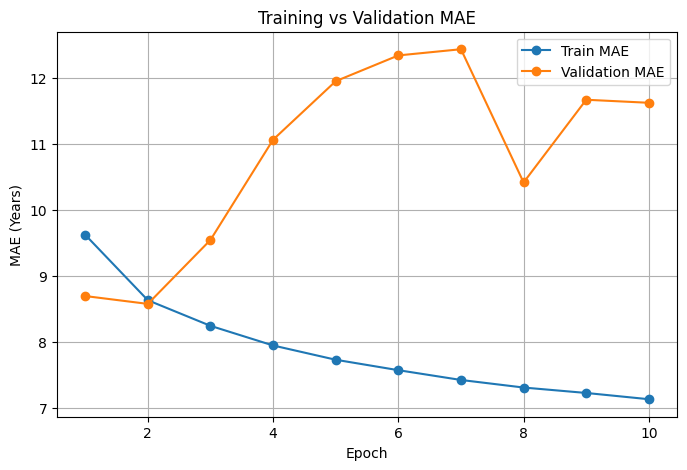

In [29]:
epochs_range = range(1, len(train_mae_list) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_mae_list, marker="o", label="Train MAE")
plt.plot(epochs_range, val_mae_list, marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (Years)")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
best_model = AgeCNN().to(device)
best_model.load_state_dict(torch.load("best_age_cnn.pth", map_location=device))
best_model.eval()

AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [31]:
for i in range(10):
    image, true_age = val_dataset[i]
    with torch.no_grad():
        pred_age = best_model(image.unsqueeze(0).to(device)).item()
    print(f"Sample {i+1} -> True age: {true_age.item():.0f}, Predicted age: {pred_age:.2f}")


plt.figure(figsize=(15, 8))

Sample 1 -> True age: 57, Predicted age: 61.09
Sample 2 -> True age: 57, Predicted age: 52.59
Sample 3 -> True age: 57, Predicted age: 35.76
Sample 4 -> True age: 57, Predicted age: 32.14
Sample 5 -> True age: 57, Predicted age: 35.69
Sample 6 -> True age: 57, Predicted age: 40.87
Sample 7 -> True age: 57, Predicted age: 50.72
Sample 8 -> True age: 57, Predicted age: 64.55
Sample 9 -> True age: 57, Predicted age: 56.41
Sample 10 -> True age: 57, Predicted age: 56.58


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

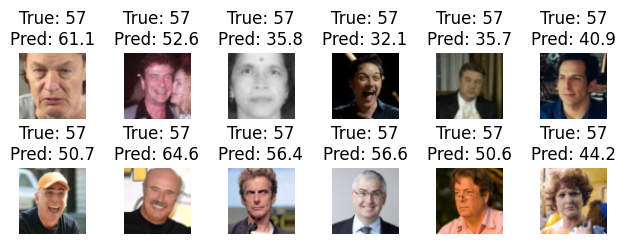

In [32]:
for i in range(12):
    image, true_age = val_dataset[i]

    with torch.no_grad():
        pred_age = best_model(image.unsqueeze(0).to(device)).item()

    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    plt.subplot(4, 6, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_age.item():.0f}\nPred: {pred_age:.1f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
best_model = AgeCNN().to(device)
best_model.load_state_dict(torch.load("best_age_cnn.pth", map_location=device))
best_model.eval()

AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

Pre-Trained

In [34]:
from torchvision import models

In [35]:
class AgeResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [36]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [37]:
train_dataset = AgeDataset(path, split="train", transform=train_transform)
val_dataset = AgeDataset(path, split="test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [38]:
model = AgeResNet().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


In [39]:
train_mae_list = []
val_mae_list = []
best_val_loss = float("inf")
epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, ages in train_loader:
        images = images.to(device, non_blocking=True)
        ages = ages.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0
    within_5 = 0
    within_10 = 0
    total = 0

    with torch.no_grad():
        for images, ages in val_loader:
            images = images.to(device, non_blocking=True)
            ages = ages.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, ages)
            val_loss += loss.item()

            diff = torch.abs(outputs - ages)
            within_5 += (diff <= 5).sum().item()
            within_10 += (diff <= 10).sum().item()
            total += ages.size(0)

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_mae_list.append(train_loss)
    val_mae_list.append(val_loss)

    acc_within_5 = 100 * within_5 / total
    acc_within_10 = 100 * within_10 / total

    print(
        f"Epoch {epoch+1}/{epochs} - "
        f"Train MAE: {train_loss:.4f} - "
        f"Val MAE: {val_loss:.4f} - "
        f"Within ±5 years: {acc_within_5:.2f}% - "
        f"Within ±10 years: {acc_within_10:.2f}%"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_age_resnet18.pth")
        print("Best pretrained model saved!")

Epoch 1/10 - Train MAE: 7.9884 - Val MAE: 6.6349 - Within ±5 years: 50.39% - Within ±10 years: 79.21%
Best pretrained model saved!
Epoch 2/10 - Train MAE: 6.9456 - Val MAE: 6.1994 - Within ±5 years: 53.01% - Within ±10 years: 81.51%
Best pretrained model saved!
Epoch 3/10 - Train MAE: 6.6666 - Val MAE: 5.9618 - Within ±5 years: 54.93% - Within ±10 years: 82.86%
Best pretrained model saved!
Epoch 4/10 - Train MAE: 6.4682 - Val MAE: 5.9713 - Within ±5 years: 55.00% - Within ±10 years: 82.98%
Epoch 5/10 - Train MAE: 6.3101 - Val MAE: 5.9594 - Within ±5 years: 55.30% - Within ±10 years: 82.96%
Best pretrained model saved!
Epoch 6/10 - Train MAE: 6.1889 - Val MAE: 5.7379 - Within ±5 years: 56.97% - Within ±10 years: 84.15%
Best pretrained model saved!
Epoch 7/10 - Train MAE: 6.0806 - Val MAE: 5.8035 - Within ±5 years: 56.56% - Within ±10 years: 83.77%
Epoch 8/10 - Train MAE: 5.9937 - Val MAE: 5.7037 - Within ±5 years: 57.42% - Within ±10 years: 84.49%
Best pretrained model saved!
Epoch 9/10

In [40]:
best_model = AgeResNet().to(device)
best_model.load_state_dict(torch.load("best_age_resnet18.pth", map_location=device))
best_model.eval()

AgeResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

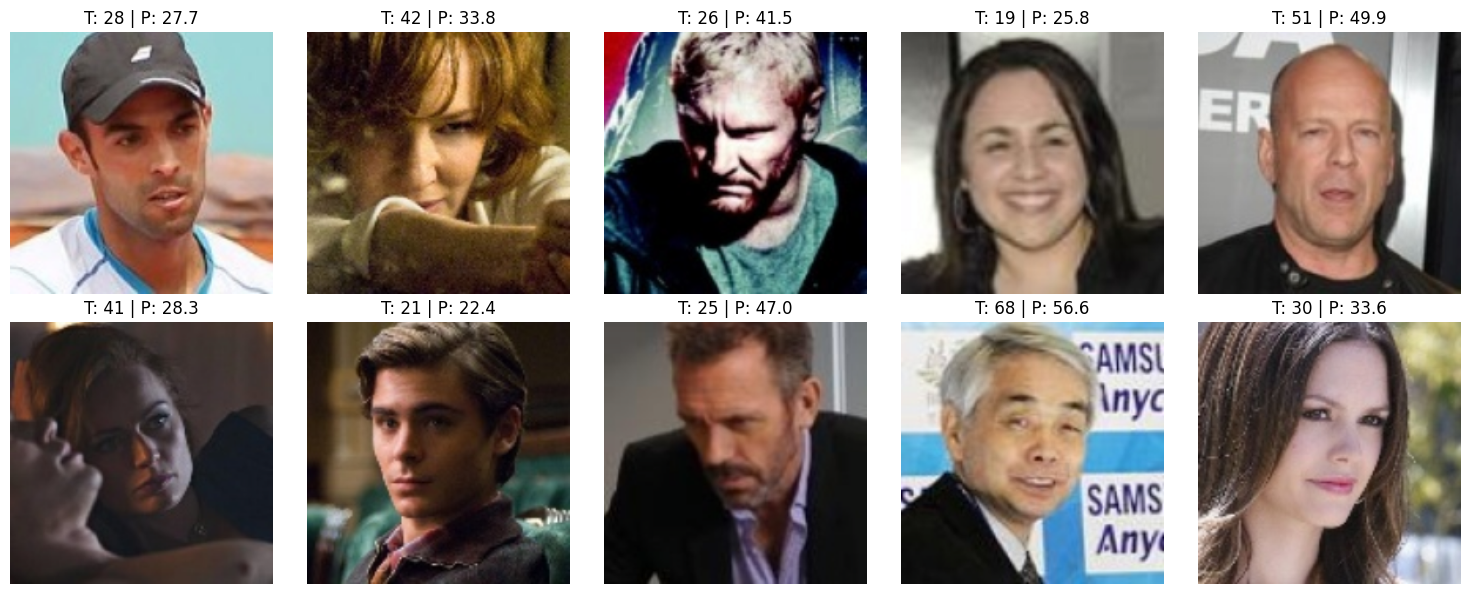

In [49]:
import random
import matplotlib.pyplot as plt

best_model.eval()

plt.figure(figsize=(15, 6))

indices = random.sample(range(len(val_dataset)), 10)

for i, idx in enumerate(indices):
    image, true_age = val_dataset[idx]

    with torch.no_grad():
        pred_age = best_model(image.unsqueeze(0).to(device)).item()

    img = image.permute(1, 2, 0).cpu().numpy()

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img = std * img + mean
    img = img.clip(0, 1)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"T: {true_age.item():.0f} | P: {pred_age:.1f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
plt